In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data from R
df = pd.read_csv("../outputs/credit_default_clean.csv")

print(df.shape)

(30000, 25)


In [4]:
# Feature Engineering

# 1. Average payment delay across 6 months
df['avg_payment_delay'] = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].mean(axis=1)

# 2. Number of months with payment delay (delay > 0)
df['months_delayed'] = (df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']] > 0).sum(axis=1)

# 3. Average bill amount over 6 months
df['avg_bill_amt'] = df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)

# 4. Average payment amount over 6 months
df['avg_pay_amt'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)

# 5. Bill to credit limit ratio (how much of their limit they are using)
df['bill_to_limit_ratio'] = df['avg_bill_amt'] / (df['LIMIT_BAL'] + 1)

# 6. Payment to bill ratio (how much of their bill they actually pay)
df['pay_to_bill_ratio'] = df['avg_pay_amt'] / (df['avg_bill_amt'].abs() + 1)

# 7. Consecutive delayed payments (PAY_0 and PAY_2 both delayed)
df['consecutive_delay'] = ((df['PAY_0'] > 0) & (df['PAY_2'] > 0)).astype(int)

print("New features added:")
print(df[['avg_payment_delay', 'months_delayed', 'bill_to_limit_ratio', 
          'pay_to_bill_ratio', 'consecutive_delay']].describe())

New features added:
       avg_payment_delay  months_delayed  bill_to_limit_ratio  \
count       30000.000000    30000.000000         30000.000000   
mean           -0.182439        0.834200             0.373041   
std             0.982176        1.554303             0.351882   
min            -2.000000        0.000000            -0.232585   
25%            -0.833333        0.000000             0.029997   
50%             0.000000        0.000000             0.284829   
75%             0.000000        1.000000             0.687927   
max             6.000000        6.000000             5.364040   

       pay_to_bill_ratio  consecutive_delay  
count       30000.000000       30000.000000  
mean            3.984841           0.133033  
std           209.398071           0.339616  
min             0.000000           0.000000  
25%             0.041302           0.000000  
50%             0.087862           0.000000  
75%             0.608411           0.000000  
max         27000.000000  

In [5]:
# Cap extreme values in pay_to_bill_ratio
df['pay_to_bill_ratio'] = df['pay_to_bill_ratio'].clip(upper=5)

# Save engineered dataset
df.to_csv("../outputs/credit_default_engineered.csv", index=False)

print("Feature engineering complete.")
print(f"Final dataset shape: {df.shape}")
print(f"Total features: {df.shape[1] - 1} (excluding target)")

Feature engineering complete.
Final dataset shape: (30000, 32)
Total features: 31 (excluding target)


In [6]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# Load engineered data
df = pd.read_csv("../outputs/credit_default_engineered.csv")

# Define features and target
X = df.drop(columns=["ID", "default"])
y = df["default"]

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")

Features: 30
Target distribution:
default
0    0.779
1    0.221
Name: proportion, dtype: float64


In [8]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

# Convert SEX, EDUCATION, MARRIAGE back to numeric
le = LabelEncoder()
df['SEX'] = le.fit_transform(df['SEX'])  # Male=0, Female=1

# EDUCATION and MARRIAGE may also have come in as strings
df['EDUCATION'] = pd.to_numeric(df['EDUCATION'], errors='coerce')
df['MARRIAGE'] = pd.to_numeric(df['MARRIAGE'], errors='coerce')

# Redefine X and y after encoding
X = df.drop(columns=["ID", "default"])
y = df["default"]

# Redo train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Default rate in train: {y_train.mean():.3f}")
print(f"Default rate in test: {y_test.mean():.3f}")

Training set: 24000 samples
Test set: 6000 samples
Default rate in train: 0.221
Default rate in test: 0.221


In [10]:
# Train models
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 3. XGBoost (scale_pos_weight handles class imbalance)
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     scale_pos_weight=scale, eval_metric="logloss")
xgb.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [11]:
# Evaluate all models
models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test)
}

results = {}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {"auc": auc, "y_pred": y_pred, "y_prob": y_prob}
    
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))


Logistic Regression
ROC-AUC: 0.7398
              precision    recall  f1-score   support

  No Default       0.82      0.96      0.89      4673
     Default       0.65      0.28      0.39      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000


Random Forest
ROC-AUC: 0.7578
              precision    recall  f1-score   support

  No Default       0.84      0.94      0.89      4673
     Default       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000


XGBoost
ROC-AUC: 0.7529
              precision    recall  f1-score   support

  No Default       0.87      0.80      0.83      4673
     Default       0.45      0.57      0.50      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.69  

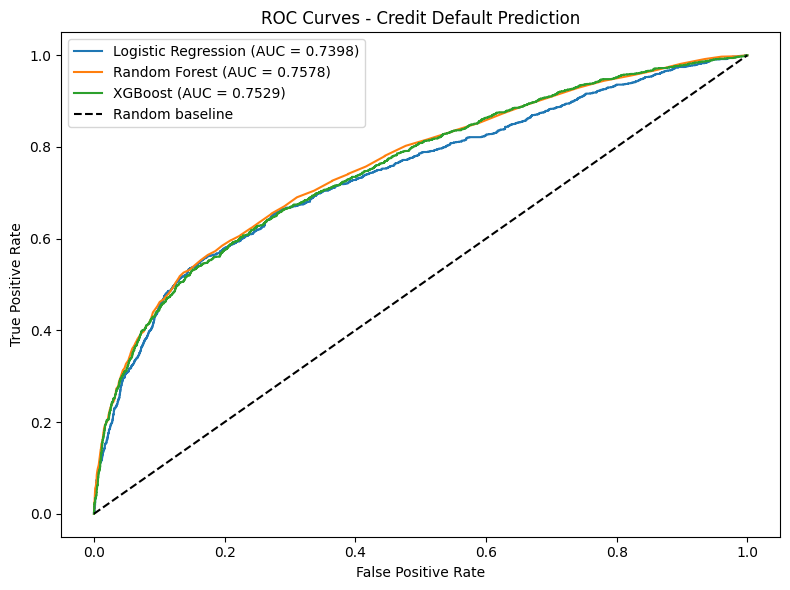

/var/folders/fr/w0dtk6qd7y1cllymsfbtvqw00000gn/T/ipykernel_8576/1296057996.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="Blues_r")


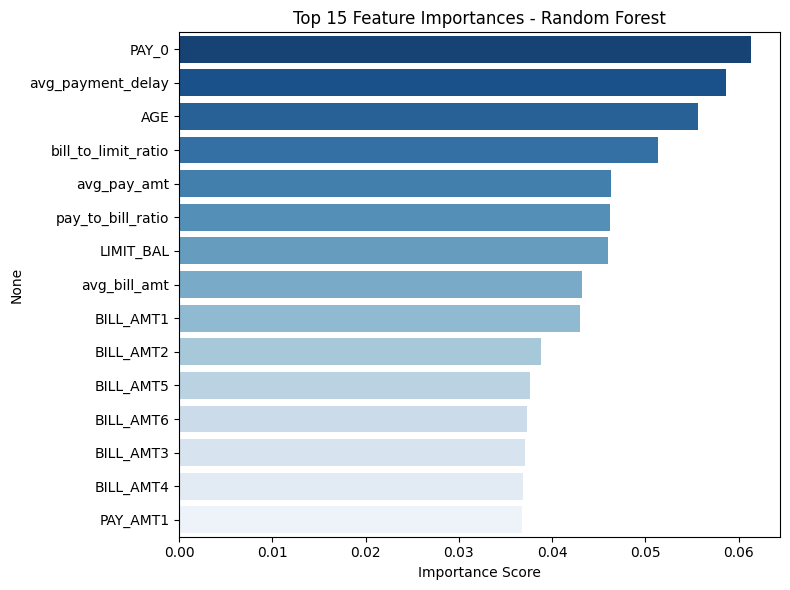

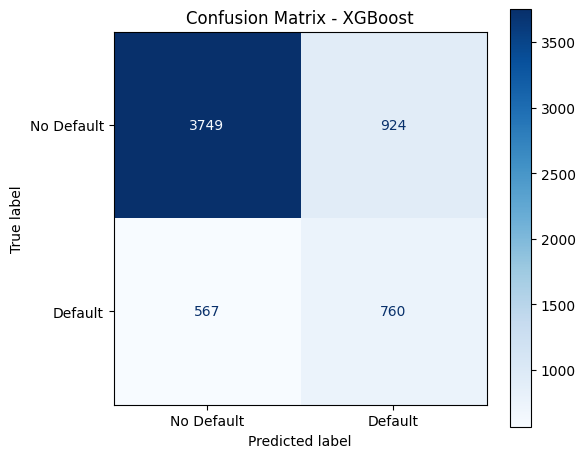

All visualisations saved.


In [12]:
# Plot ROC curves for all models
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Credit Default Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/07_roc_curves.png", dpi=150)
plt.show()

# Feature importance from Random Forest
feature_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="Blues_r")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../outputs/08_feature_importance.png", dpi=150)
plt.show()

# Confusion matrix for XGBoost (best recall on defaulters)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, results["XGBoost"]["y_pred"],
    display_labels=["No Default", "Default"],
    cmap="Blues", ax=ax
)
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.savefig("../outputs/09_confusion_matrix_xgb.png", dpi=150)
plt.show()

print("All visualisations saved.")

In [13]:
# Save results summary for Tableau
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC_AUC": [results["Logistic Regression"]["auc"],
                results["Random Forest"]["auc"],
                results["XGBoost"]["auc"]],
    "Accuracy": [0.81, 0.81, 0.75],
    "Default_Recall": [0.28, 0.36, 0.57],
    "Default_Precision": [0.65, 0.63, 0.45]
})

summary.to_csv("../outputs/model_results.csv", index=False)

# Save feature importance for Tableau
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_df.to_csv("../outputs/feature_importance.csv", index=False)

print("Results exported for Tableau.")
print(summary.to_string(index=False))

Results exported for Tableau.
              Model  ROC_AUC  Accuracy  Default_Recall  Default_Precision
Logistic Regression 0.739757      0.81            0.28               0.65
      Random Forest 0.757800      0.81            0.36               0.63
            XGBoost 0.752895      0.75            0.57               0.45


In [14]:
# Improve XGBoost with tuned threshold
# Instead of default 0.5 threshold, lower it to catch more defaulters
y_prob_xgb = results["XGBoost"]["y_prob"]

# Try threshold of 0.3
y_pred_tuned = (y_prob_xgb >= 0.3).astype(int)

print("XGBoost with threshold 0.3:")
print(classification_report(y_test, y_pred_tuned, 
      target_names=["No Default", "Default"]))

XGBoost with threshold 0.3:
              precision    recall  f1-score   support

  No Default       0.89      0.60      0.72      4673
     Default       0.34      0.74      0.47      1327

    accuracy                           0.63      6000
   macro avg       0.62      0.67      0.59      6000
weighted avg       0.77      0.63      0.66      6000



In [15]:
# Save tuned threshold results
tuned_summary = pd.DataFrame({
    "Model": ["XGBoost (threshold=0.5)", "XGBoost (threshold=0.3)"],
    "ROC_AUC": [results["XGBoost"]["auc"], results["XGBoost"]["auc"]],
    "Accuracy": [0.75, 0.63],
    "Default_Recall": [0.57, 0.74],
    "Default_Precision": [0.45, 0.34]
})

tuned_summary.to_csv("../outputs/tuned_results.csv", index=False)
print("Tuned results saved.")

Tuned results saved.
